In [1]:
import pandas as pd
import gzip
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import csv

PATH = r"C:\Users\meaga\Downloads\smdm\train-balanced-sarc.csv"  # change if needed

# Try gzip, fall back to normal CSV
try:
    with gzip.open(PATH, "rt", encoding="utf-8") as f:
        df = pd.read_csv(f, sep="\t", header=None, names=[
            "label", "comment", "author", "subreddit", 
            "score", "ups", "downs", "date", "created_utc", "parent_comment"
        ])
except:
    df = pd.read_csv(PATH, sep="\t", header=None, names=[
        "label", "comment", "author", "subreddit", 
        "score", "ups", "downs", "date", "created_utc", "parent_comment"
    ])

df.head()


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,1476662123,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,1477959850,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,1474580737,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,1476824627,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,1483117213,Yep can confirm I saw the tool they use for th...


In [3]:
df = df.dropna(subset=["comment"])
df["label"] = df["label"].astype(int)

df.head()


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,1476662123,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,1477959850,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,1474580737,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,1476824627,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,1483117213,Yep can confirm I saw the tool they use for th...


In [4]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(str(text))["compound"]

df["sentiment"] = df["comment"].apply(get_sentiment)

df.head()


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment,sentiment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,1476662123,"Yeah, I get that argument. At this point, I'd ...",0.0000
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,1477959850,The blazers and Mavericks (The wests 5 and 6 s...,0.3400
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,1474580737,They're favored to win.,0.0000
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,1476824627,deadass don't kill my buzz,-0.3412
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,1483117213,Yep can confirm I saw the tool they use for th...,0.0000


In [5]:
sarcastic = df[df["label"] == 1]["sentiment"]
nonsarcastic = df[df["label"] == 0]["sentiment"]

print("Avg sarcastic sentiment:", sarcastic.mean())
print("Avg non-sarcastic sentiment:", nonsarcastic.mean())


Avg sarcastic sentiment: 0.0669428137515632
Avg non-sarcastic sentiment: 0.061692502220999895


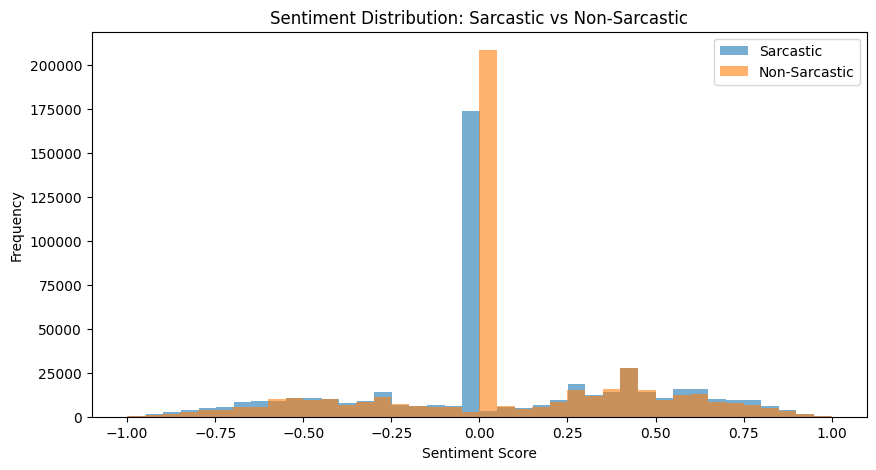

In [6]:
plt.figure(figsize=(10,5))
plt.hist(sarcastic, bins=40, alpha=0.6, label="Sarcastic")
plt.hist(nonsarcastic, bins=40, alpha=0.6, label="Non-Sarcastic")
plt.legend()
plt.title("Sentiment Distribution: Sarcastic vs Non-Sarcastic")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()


In [7]:
subreddit_stats = df.groupby("subreddit")["sentiment"].mean().sort_values(ascending=False)
subreddit_stats.head(20)


subreddit
7CupsofTea             0.9360
mediacomposing         0.9359
ecuador                0.9287
americanpirateparty    0.9273
phenibut               0.9254
beforesandafters       0.9228
1200isplentyketo       0.9222
mensa                  0.9217
BattleBornTap          0.9215
Mankato                0.9186
ImaginaryOverwatch     0.9186
KarakuraTown           0.9186
pasadena               0.9168
hockeycards            0.9158
TheDevilDogGamer       0.9140
PixelClash             0.9136
iFunny                 0.9129
UKhistory              0.9124
thegreatwarpowers      0.9100
occupylosangeles       0.9089
Name: sentiment, dtype: float64

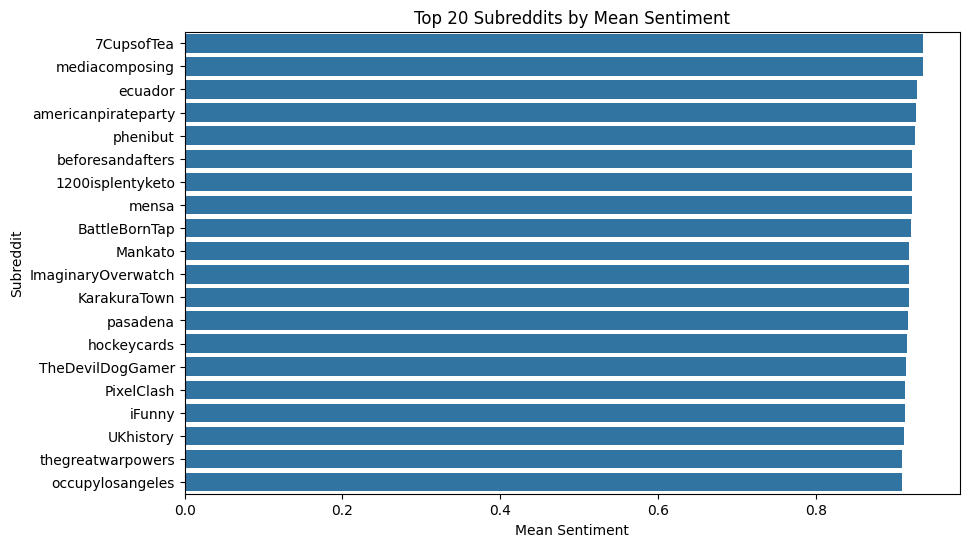

In [8]:
top20 = subreddit_stats.head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top20.values, y=top20.index)
plt.title("Top 20 Subreddits by Mean Sentiment")
plt.xlabel("Mean Sentiment")
plt.ylabel("Subreddit")
plt.show()


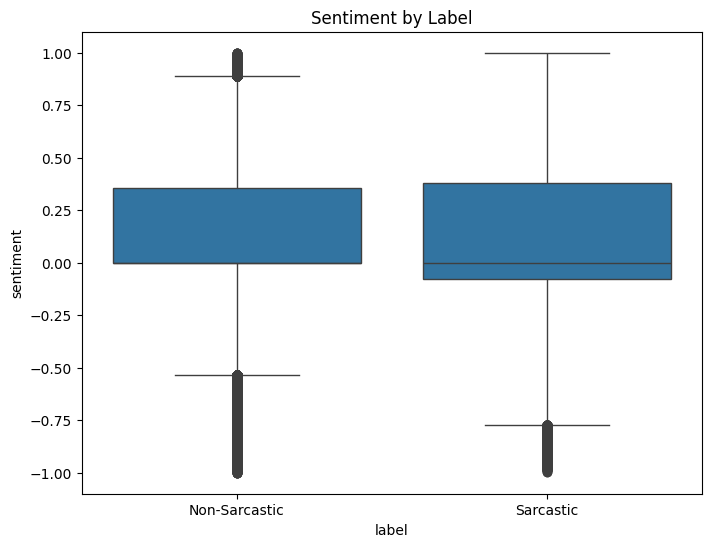

In [9]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["label"], y=df["sentiment"])
plt.xticks([0,1], ["Non-Sarcastic", "Sarcastic"])
plt.title("Sentiment by Label")
plt.show()
